# **Imports**

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings("ignore")

device = torch.device("xpu" if torch.xpu.is_available() else "cpu")
print("Using device:", device)

Using device: xpu


# **Paths & Data Load**

In [2]:
BASE_DIR = "../../data"
TRAIN_DIR = os.path.join(BASE_DIR, "train_images")

df = pd.read_csv(os.path.join(BASE_DIR, "train.csv"))

with open(os.path.join(BASE_DIR, "label_num_to_disease_map.json")) as f:
    label_map = json.load(f)
label_map = {int(k): v for k, v in label_map.items()}

df["disease_name"] = df["label"].map(label_map)
num_classes = df["label"].nunique()

print("Total images:", len(df))
print("Number of classes:", num_classes)
df.head()

Total images: 21397
Number of classes: 5


,image_id,label,disease_name
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)


# **Train / Validation / Test Split (Stratified)**

In [3]:
# First split: train (70%) vs temp (30%)
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)

# Second split: temp -> validation (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

# Verify class distribution is preserved
print("\nTrain class distribution:")
print(train_df["label"].value_counts(normalize=True).sort_index())

Train size: 14977
Validation size: 3210
Test size: 3210

Train class distribution:
label
0    0.050811
1    0.102290
2    0.111504
3    0.614943
4    0.120451
Name: proportion, dtype: float64


# **Handle Class Imbalance (Class Weights)**

In [4]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

Class weights: tensor([3.9361, 1.9552, 1.7937, 0.3252, 1.6604], device='xpu:0')


# **Data Augmentation & Normalization**

In [5]:
IMG_SIZE = 224  # standard input size for most pretrained CNNs

# Training transforms: includes augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                          std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms: no augmentation, only resize + normalize
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

# **Custom Dataset Class**

In [6]:
import sys
sys.path.append("../../")  

from dataset_utils import CassavaDataset

train_dataset = CassavaDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset = CassavaDataset(val_df, TRAIN_DIR, transform=eval_transform)
test_dataset = CassavaDataset(test_df, TRAIN_DIR, transform=eval_transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=4, persistent_workers=True, pin_memory=True,
                           drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, persistent_workers=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, persistent_workers=True, pin_memory=True)

print("Batches -> Train:", len(train_loader), "Val:", len(val_loader), "Test:", len(test_loader))

Batches -> Train: 468 Val: 101 Test: 101


# **Helper Functions: Train, Evaluate, Metrics, Param Count**

In [7]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    return total

def get_model_size_mb(model):
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in model.buffers())
    return (param_size + buffer_size) / (1024 ** 2)

def train_one_epoch(model, loader, optimizer, criterion, epoch_num, total_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Progress bar for this epoch's batches (shows how much of the epoch is done)
    pbar = tqdm(loader, desc=f"Epoch {epoch_num}/{total_epochs} [Train]", leave=False)

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Live batch-level stats shown on the progress bar itself
        pbar.set_postfix({
            "batch_loss": f"{loss.item():.4f}",
            "running_acc": f"{correct/total:.4f}"
        })

    return running_loss / total, correct / total

def evaluate(model, loader, criterion, desc="Val"):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc=f"[{desc}]", leave=False)

    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="macro")
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    per_class_recall = recall_score(all_labels, all_preds, average=None, zero_division=0)

    return avg_loss, acc, f1, precision, recall, per_class_recall, all_preds, all_labels

# **Full Training Loop Function (Reusable for Every Baseline)**

In [8]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

def run_training_fair(model, model_name, max_epochs=10, lr=0.0001, patience=4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_f1 = 0.0
    best_state = None
    epochs_no_improve = 0
    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, epoch, max_epochs)
        val_loss, val_acc, val_f1, val_prec, val_rec, _, _, _ = evaluate(model, val_loader, criterion, "Validation")
        scheduler.step(val_f1)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(f"[{model_name}] Epoch {epoch}/{max_epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} Macro-F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch} (best Macro-F1: {best_f1:.4f})")
                break

    model.load_state_dict(best_state)
    training_time = time.time() - start_time

    test_loss, test_acc, test_f1, test_prec, test_rec, test_per_class_recall, test_preds, test_labels = evaluate(model, test_loader, criterion, "Test")

    total_params = count_parameters(model)
    model_size = get_model_size_mb(model)

    results = {
        "model_name": model_name, "test_f1_macro": test_f1, "test_recall_macro": test_rec,
        "test_precision_macro": test_prec, "test_accuracy": test_acc,
        "test_per_class_recall": test_per_class_recall, "training_time_sec": training_time,
        "total_params": total_params, "model_size_mb": model_size, "history": history,
        "test_preds": test_preds, "test_labels": test_labels
    }

    print(f"\n[{model_name}] FINAL TEST -> Macro-F1: {test_f1:.4f} | Accuracy: {test_acc:.4f} | "
          f"Params: {total_params:,} | Time: {training_time:.1f}s\n")

    return model, results

# **Baseline 1: Simple CNN (from scratch, no pretraining)**

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

simple_cnn = SimpleCNN(num_classes=num_classes)
simple_cnn, results_simplecnn = run_training_fair(simple_cnn, "SimpleCNN", max_epochs=10, lr=0.0005, patience=4)

Epoch 1/10 [Train]:   0%|          | 0/468 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[SimpleCNN] Epoch 1/10 | Train Loss: 1.4591 Acc: 0.4378 | Val Loss: 1.5837 Acc: 0.6053 Macro-F1: 0.3265


Epoch 2/10 [Train]:   0%|          | 0/468 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

...

Epoch 10/10 [Train]:   0%|          | 0/468 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[SimpleCNN] Epoch 10/10 | Train Loss: 1.0484 Acc: 0.6464 | Val Loss: 1.0428 Acc: 0.6196 Macro-F1: 0.5230


[Test]:   0%|          | 0/101 [00:00<?, ?it/s]


[SimpleCNN] FINAL TEST -> Macro-F1: 0.5289 | Accuracy: 0.6255 | Params: 390,661 | Time: 325.5s



# **Baseline 2: MobileNetV2 (pretrained, lightweight)**

In [10]:
mobilenet = models.mobilenet_v2(weights="IMAGENET1K_V1")
mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, num_classes)
mobilenet, results_mobilenet = run_training_fair(mobilenet, "MobileNetV2", max_epochs=10, lr=0.0001, patience=4)

Epoch 1/10 [Train]:   0%|          | 0/468 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[MobileNetV2] Epoch 1/10 | Train Loss: 1.0169 Acc: 0.6590 | Val Loss: 0.8529 Acc: 0.7187 Macro-F1: 0.6170


Epoch 2/10 [Train]:   0%|          | 0/468 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

...

Epoch 10/10 [Train]:   0%|          | 0/468 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[MobileNetV2] Epoch 10/10 | Train Loss: 0.4624 Acc: 0.8473 | Val Loss: 0.7336 Acc: 0.7975 Macro-F1: 0.6990
Early stopping triggered at epoch 10 (best Macro-F1: 0.7037)


[Test]:   0%|          | 0/101 [00:00<?, ?it/s]


[MobileNetV2] FINAL TEST -> Macro-F1: 0.6884 | Accuracy: 0.7907 | Params: 2,230,277 | Time: 560.8s



# **Baseline 3: ResNet50 (pretrained, heavier)**

In [11]:
resnet50 = models.resnet50(weights="IMAGENET1K_V1")
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)
resnet50, results_resnet50 = run_training_fair(resnet50, "ResNet50", max_epochs=10, lr=0.0001, patience=4)

Epoch 1/10 [Train]:   0%|          | 0/468 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[ResNet50] Epoch 1/10 | Train Loss: 0.9938 Acc: 0.6695 | Val Loss: 0.8056 Acc: 0.7891 Macro-F1: 0.6728


Epoch 2/10 [Train]:   0%|          | 0/468 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

...

Epoch 10/10 [Train]:   0%|          | 0/468 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[ResNet50] Epoch 10/10 | Train Loss: 0.4299 Acc: 0.8636 | Val Loss: 0.7332 Acc: 0.8075 Macro-F1: 0.7066


[Test]:   0%|          | 0/101 [00:00<?, ?it/s]


[ResNet50] FINAL TEST -> Macro-F1: 0.7052 | Accuracy: 0.8093 | Params: 23,518,277 | Time: 1033.8s



# **Baseline 4: EfficientNet-B0 (pretrained)**

In [12]:
effnet = models.efficientnet_b0(weights="IMAGENET1K_V1")
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, num_classes)
effnet, results_effnet = run_training_fair(effnet, "EfficientNet-B0", max_epochs=10, lr=0.0001, patience=4)

Epoch 1/10 [Train]:   0%|          | 0/468 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[EfficientNet-B0] Epoch 1/10 | Train Loss: 1.0794 Acc: 0.6490 | Val Loss: 0.8614 Acc: 0.7421 Macro-F1: 0.6314


Epoch 2/10 [Train]:   0%|          | 0/468 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

...

Epoch 10/10 [Train]:   0%|          | 0/468 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[EfficientNet-B0] Epoch 10/10 | Train Loss: 0.3605 Acc: 0.8809 | Val Loss: 0.9234 Acc: 0.8134 Macro-F1: 0.7090


[Test]:   0%|          | 0/101 [00:00<?, ?it/s]


[EfficientNet-B0] FINAL TEST -> Macro-F1: 0.7186 | Accuracy: 0.8224 | Params: 4,013,953 | Time: 662.6s



# **Final Baseline Summary Table**

In [13]:
all_results = [results_simplecnn, results_mobilenet, results_resnet50, results_effnet]

summary_table = pd.DataFrame([{
    "Model": r["model_name"],
    "Macro F1 (Primary Metric)": round(r["test_f1_macro"], 4),
    "Macro Recall": round(r["test_recall_macro"], 4),
    "Macro Precision": round(r["test_precision_macro"], 4),
    "Test Accuracy": round(r["test_accuracy"], 4),
    "Training Time (s)": round(r["training_time_sec"], 1),
    "Total Params": f"{r['total_params']:,}",
    "Model Size (MB)": round(r["model_size_mb"], 2)
} for r in all_results])

# Sort by primary metric (macro-F1), not accuracy
summary_table = summary_table.sort_values("Macro F1 (Primary Metric)", ascending=False)

print(summary_table.to_string(index=False))
summary_table.to_csv("baseline_results_summary.csv", index=False)

          Model  Macro F1 (Primary Metric)  Macro Recall  Macro Precision  Test Accuracy  Training Time (s) Total Params  Model Size (MB)
EfficientNet-B0                     0.7186        0.7450           0.6977         0.8224              662.6    4,013,953            15.47
       ResNet50                     0.7052        0.7464           0.6784         0.8093             1033.8   23,518,277            89.92
    MobileNetV2                     0.6884        0.7327           0.6619         0.7907              560.8    2,230,277             8.64
      SimpleCNN                     0.5289        0.6029           0.5016         0.6255              325.5      390,661             1.49


# **Classification Report for Each Baseline**

In [14]:
class_names = [label_map[i] for i in range(num_classes)]

for r in all_results:
    print(f"\n===== Classification Report: {r['model_name']} =====")
    print(classification_report(r["test_labels"], r["test_preds"], target_names=class_names))


===== Classification Report: SimpleCNN =====
                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)       0.37      0.59      0.46       163
Cassava Brown Streak Disease (CBSD)       0.39      0.60      0.47       329
         Cassava Green Mottle (CGM)       0.38      0.57      0.46       358
       Cassava Mosaic Disease (CMD)       0.96      0.65      0.77      1974
                            Healthy       0.40      0.61      0.49       386

                           accuracy                           0.63      3210
                          macro avg       0.50      0.60      0.53      3210
                       weighted avg       0.74      0.63      0.66      3210


===== Classification Report: MobileNetV2 =====
                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)       0.46      0.69      0.56       163
Cassava Brown Streak Disease (CBSD)       0.74      0.6

# **Confusion Matrices**

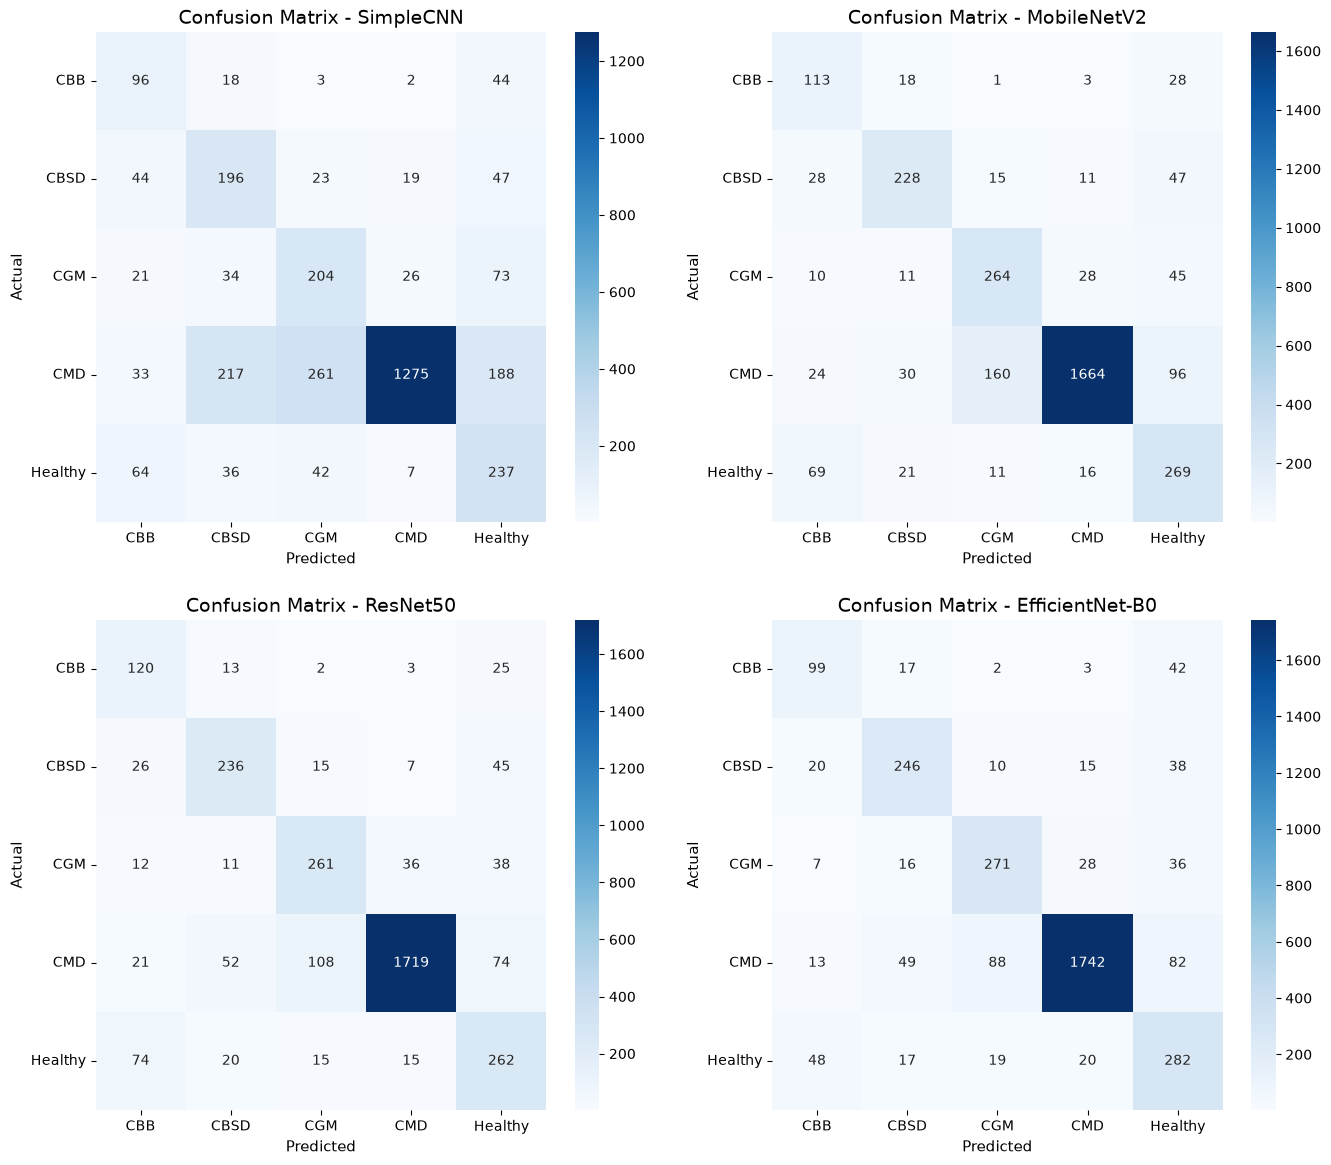

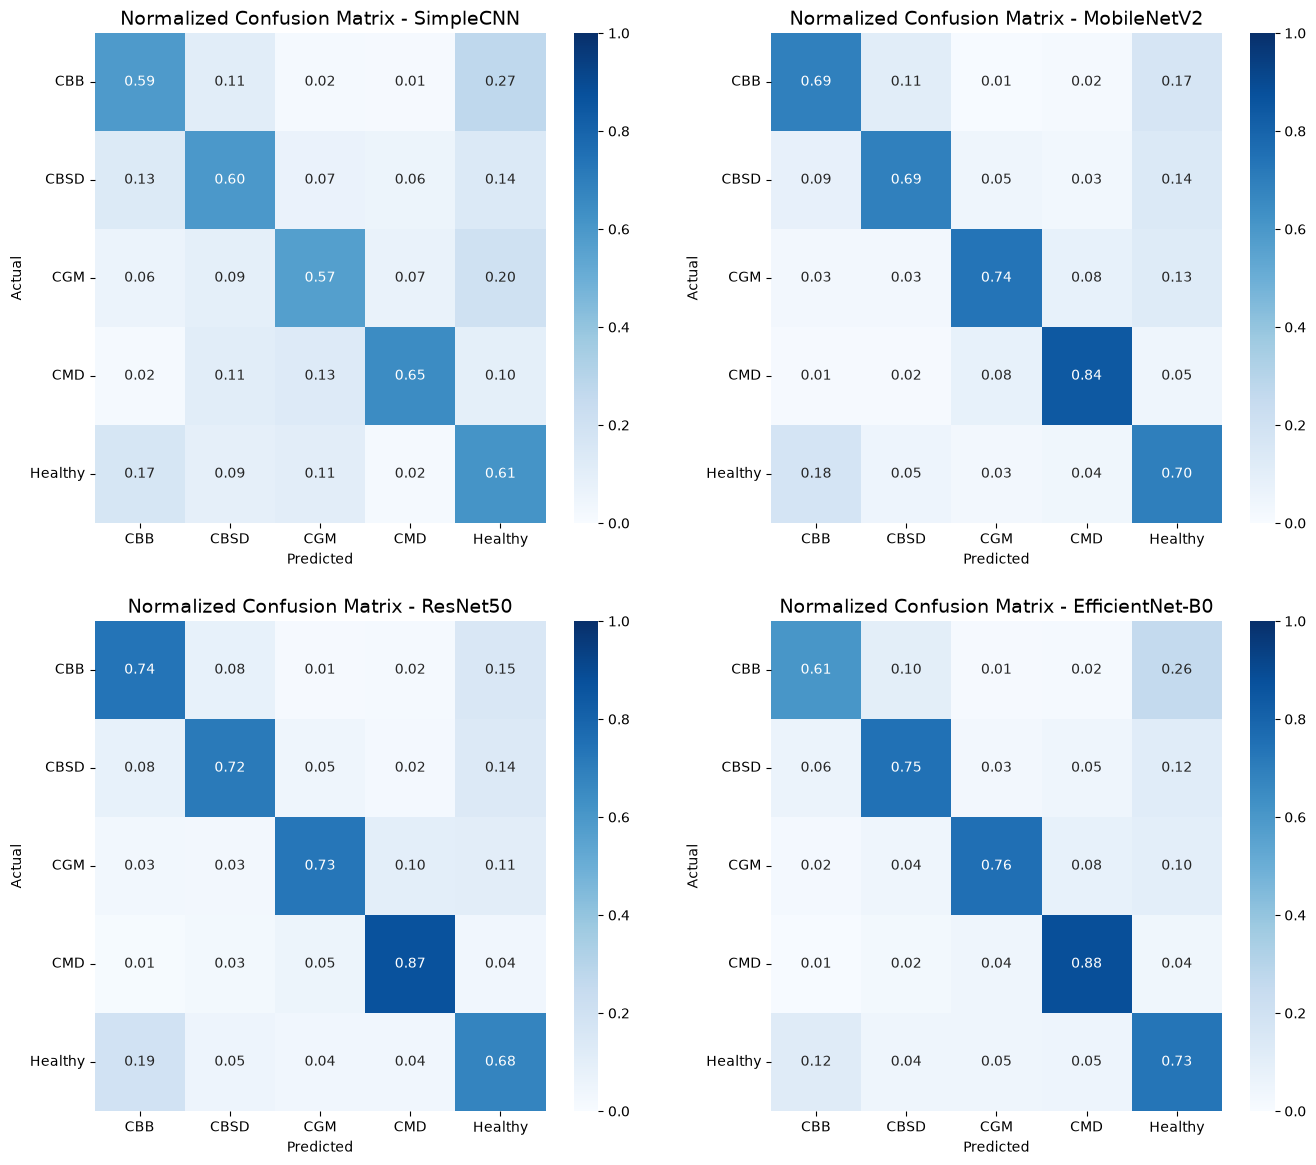

In [15]:
short_class_names = [
    "CBB",
    "CBSD",
    "CGM",
    "CMD",
    "Healthy"
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, r in enumerate(all_results):

    cm = confusion_matrix(
        r["test_labels"],
        r["test_preds"]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        xticklabels=short_class_names,
        yticklabels=short_class_names,
        annot_kws={"size": 10}
    )

    axes[i].set_title(
        f"Confusion Matrix - {r['model_name']}",
        fontsize=14
    )

    axes[i].set_xlabel("Predicted", fontsize=11)
    axes[i].set_ylabel("Actual", fontsize=11)

    axes[i].tick_params(
        axis="x",
        rotation=0,
        labelsize=10
    )

    axes[i].tick_params(
        axis="y",
        rotation=0,
        labelsize=10
    )
plt.savefig("baseline_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, r in enumerate(all_results):

    cm = confusion_matrix(
        r["test_labels"],
        r["test_preds"]
    )

    # Normalize each row
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        ax=axes[i],
        xticklabels=short_class_names,
        yticklabels=short_class_names,
        vmin=0,
        vmax=1,
        annot_kws={"size": 10}
    )

    axes[i].set_title(
        f"Normalized Confusion Matrix - {r['model_name']}",
        fontsize=14
    )

    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

    axes[i].tick_params(axis="x", rotation=0)
    axes[i].tick_params(axis="y", rotation=0)


plt.savefig("baseline_confusion_matrices_percentage.png", dpi=300, bbox_inches="tight")
plt.show()

# **Training Curves Comparison**

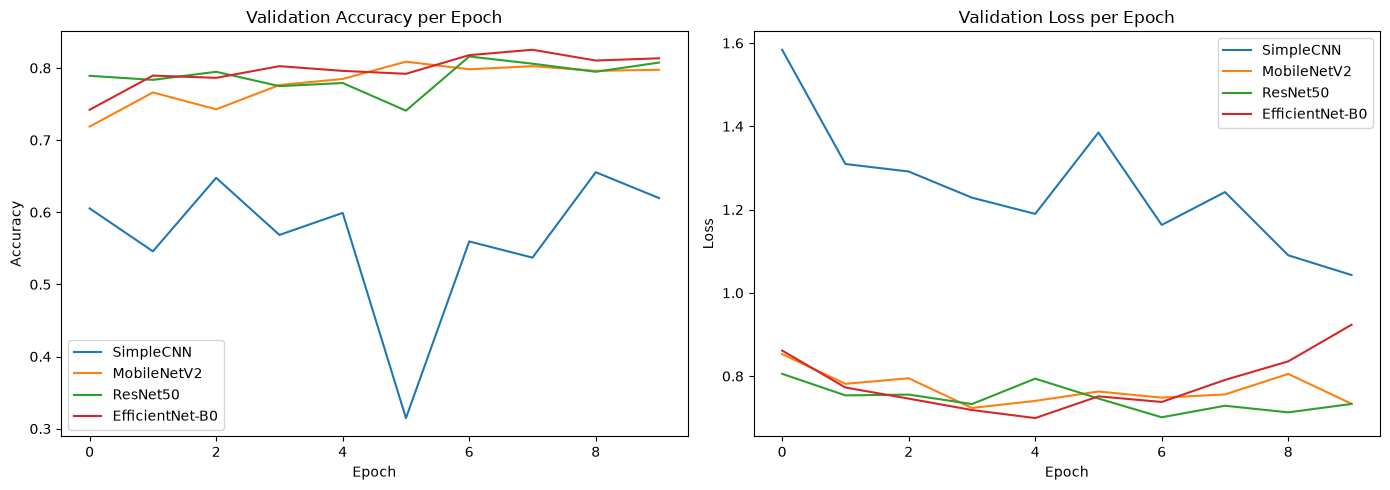

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for r in all_results:
    axes[0].plot(r["history"]["val_acc"], label=r["model_name"])
    axes[1].plot(r["history"]["val_loss"], label=r["model_name"])

axes[0].set_title("Validation Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].set_title("Validation Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("baseline_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()

# **Bar Chart: Accuracy vs Params vs Time**

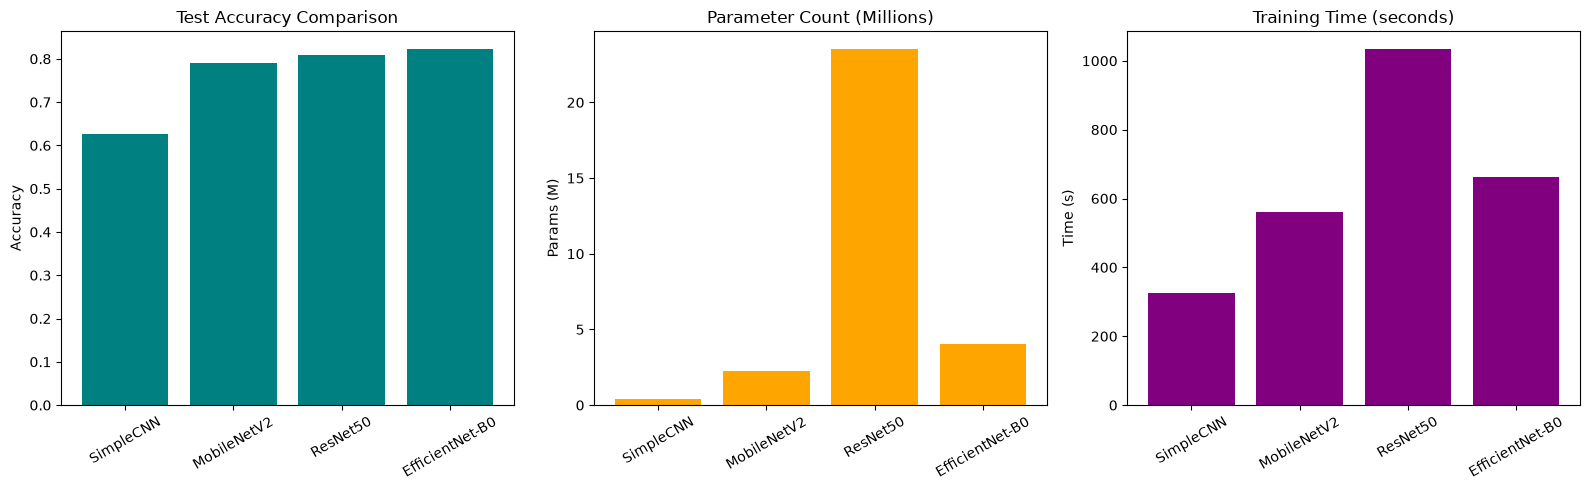

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_names = [r["model_name"] for r in all_results]
accs = [r["test_accuracy"] for r in all_results]
params = [r["total_params"]/1e6 for r in all_results]  # in millions
times = [r["training_time_sec"] for r in all_results]

axes[0].bar(models_names, accs, color="teal")
axes[0].set_title("Test Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(models_names, params, color="orange")
axes[1].set_title("Parameter Count (Millions)")
axes[1].set_ylabel("Params (M)")
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(models_names, times, color="purple")
axes[2].set_title("Training Time (seconds)")
axes[2].set_ylabel("Time (s)")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("baseline_comparison_bars.png", dpi=300, bbox_inches="tight")
plt.show()

# **Save Best Baseline Model**

In [18]:
best_baseline = max(all_results, key=lambda x: x["test_f1_macro"])
print("Best baseline model:", best_baseline["model_name"])

# Save results as JSON for reuse in the proposed model notebook
import pickle
with open("baseline_results.pkl", "wb") as f:
    pickle.dump(all_results, f)

print("Baseline results saved to baseline_results.pkl")

Best baseline model: EfficientNet-B0
Baseline results saved to baseline_results.pkl
